In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

<h3 style="text-align:center;">Đọc các file csv</h3>

In [2]:
PROCESSSED_DIR = 'processed'

In [ ]:
kpi_daily = pd.read_csv(r'C:\Users\APC\2526-LTXLDL-Project-1.5\processed\kpi_daily_2023.csv')
kpi_monthly = pd.read_csv(r'C:\Users\APC\2526-LTXLDL-Project-1.5\processed\kpi_monthly_2023.csv')
kpi_dow = pd.read_csv(r'C:\Users\APC\2526-LTXLDL-Project-1.5\processed\kpi_weekly_2023.csv')
DO_kpi = pd.read_csv(r'C:\Users\APC\2526-LTXLDL-Project-1.5\processed\kpi_DO_2023.csv')
PU_kpi = pd.read_csv(r'C:\Users\APC\2526-LTXLDL-Project-1.5\processed\kpi_PU_2023.csv')
kpi_hourly = pd.read_csv(r'C:\Users\APC\2526-LTXLDL-Project-1.5\processed\kpi_hourly_2023.csv')

In [4]:
PU_kpi[PU_kpi['PU_Zone'] == 'JFK Airport']

,PU_Zone,total_trips,total_revenue,total_distance_miles,median_duration_minutes,p95_duration_minutes,median_speed_mph,avg_passengers,trips_per_day
123,JFK Airport,1319779,1.053002e+08,21022180.64,39.616667,74.633333,24.041373,1.511971,3615.832877


In [5]:
kpi_dow

,pickup_dow,total_trips,total_revenue,median_duration_minutes,p95_duration_minutes,median_speed_mph,avg_trips_per_day,avg_revenue_per_day,index_dow_trips
0,Monday,3737583,9.989148e+07,11.633333,39.200000,9.728414,71876.596154,1.920990e+06,85.50
1,Tuesday,4399704,1.154201e+08,12.550000,38.466667,8.825441,84609.692308,2.219617e+06,100.65
2,Wednesday,4648428,1.223957e+08,12.783333,39.150000,8.702250,89392.846154,2.353764e+06,106.34
3,Thursday,4738163,1.259142e+08,12.933333,40.233333,8.647306,91118.519231,2.421428e+06,108.39
4,Friday,4449017,1.169678e+08,12.300000,39.933333,9.048041,85558.019231,2.249380e+06,101.78
5,Saturday,4731939,1.228411e+08,12.100000,37.883333,9.805310,90998.826923,2.362328e+06,108.25
6,Sunday,3968969,1.080342e+08,11.466667,39.666667,10.914864,74886.207547,2.038381e+06,89.08


In [6]:
kpi_monthly

,pickup_month,total_trips,total_revenue,total_miles,median_duration_minutes,p95_duration_minutes,median_speed_mph,percent_of_annual_trips,percent_of_annual_revenue
0,1,2479184,62388105.41,7386083.30,11.216667,33.366667,9.969120,8.08,7.69
1,2,2356276,59209355.19,6914102.23,11.516667,34.000000,9.711547,7.68,7.30
2,3,2712746,70019067.52,8151036.20,11.833333,36.883333,9.565134,8.84,8.63
3,4,2650203,69849171.67,8268305.09,12.050000,38.750000,9.666927,8.64,8.61
4,5,2823933,76035683.58,8884799.12,12.616667,40.833333,9.291541,9.21,9.37
5,6,2639798,71130116.41,8326259.46,12.400000,40.450000,9.405595,8.61,8.77
6,7,2331205,61905870.82,7449424.57,12.016667,38.916667,9.795798,7.60,7.63
7,8,2247939,59680168.46,7221214.72,12.000000,39.433333,9.795597,7.33,7.35
8,9,2255288,62289053.36,7052079.59,13.116667,43.333333,8.783396,7.35,7.68
9,10,2794509,75566335.87,8514809.80,13.016667,41.116667,8.735063,9.11,9.31


<h3 style="text-align:center;">Trưc quan hóa theo ngày</h3>

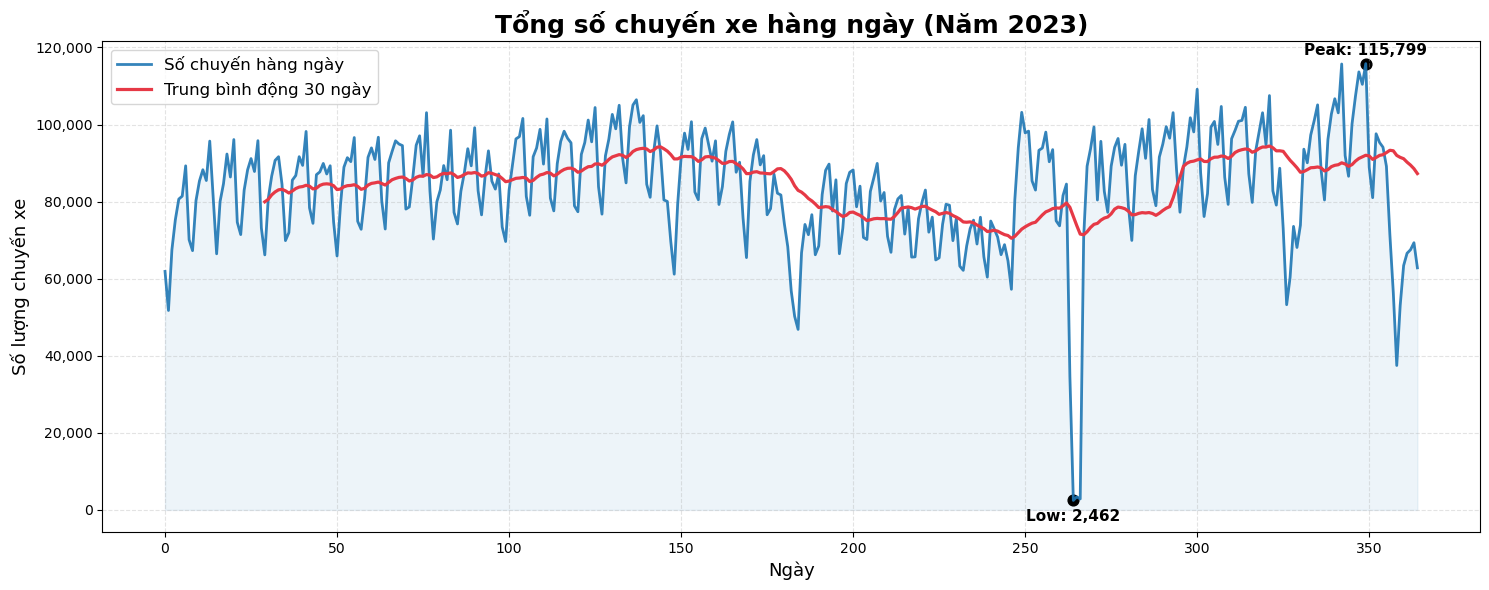

In [7]:
import matplotlib.ticker as mticker

plt.figure(figsize=(15, 6))

plt.plot(
    kpi_daily.index,
    kpi_daily['total_trips'],
    label='Số chuyến hàng ngày',
    color='#1f77b4',
    linewidth=2,
    alpha=0.9
)

plt.plot(
    kpi_daily.index,
    kpi_daily['total_trips'].rolling(window=30).mean(),
    color='#e63946',
    linewidth=2.3,
    label='Trung bình động 30 ngày'
)

plt.fill_between(
    kpi_daily.index,
    kpi_daily['total_trips'],
    color='#1f77b4',
    alpha=0.08
)

plt.title(
    'Tổng số chuyến xe hàng ngày (Năm 2023)',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Ngày', fontsize=13)
plt.ylabel('Số lượng chuyến xe', fontsize=13)

# Format
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.grid(True, linestyle='--', alpha=0.35)

# FInd peak
idx_max = kpi_daily['total_trips'].idxmax()
val_max = int(kpi_daily['total_trips'].max())

plt.scatter(idx_max, val_max, s=60, color='black')
plt.text(
    idx_max, val_max + val_max*0.02,
    f"Peak: {val_max:,}",
    ha='center',
    fontsize=11,
    fontweight='bold'
)

# Find lowest
idx_min = kpi_daily['total_trips'].idxmin()
val_min = int(kpi_daily['total_trips'].min())

plt.scatter(idx_min, val_min, s=60, color='black')
plt.text(
    idx_min, val_min - val_min*0.9,
    f"Low: {val_min:,}",
    ha='center',
    fontsize=11,
    fontweight='bold',
    va='top'
)

plt.legend(fontsize=12)

plt.tight_layout()
# plt.savefig('figures/Số chuyến đi theo ngày', dpi=150)
plt.show()
plt.close()


In [8]:
kpi_daily[kpi_daily['total_trips'] == kpi_daily['total_trips'].min()]

,pickup_date,total_trips,total_revenue,total_distance_miles,median_duration_minutes,p95_duration_minutes,median_speed_mph,avg_passengers,most_pickedup_place,most_visited_place,index_trips_100
264,2023-09-22,2462,66558.26,11160.14,18.783333,49.0,10.206111,1.001219,Upper West Side South,LaGuardia Airport,2.93


<h3 style="text-align:center;">Trực quan hóa số lượng chuyến đi theo tháng</h3>

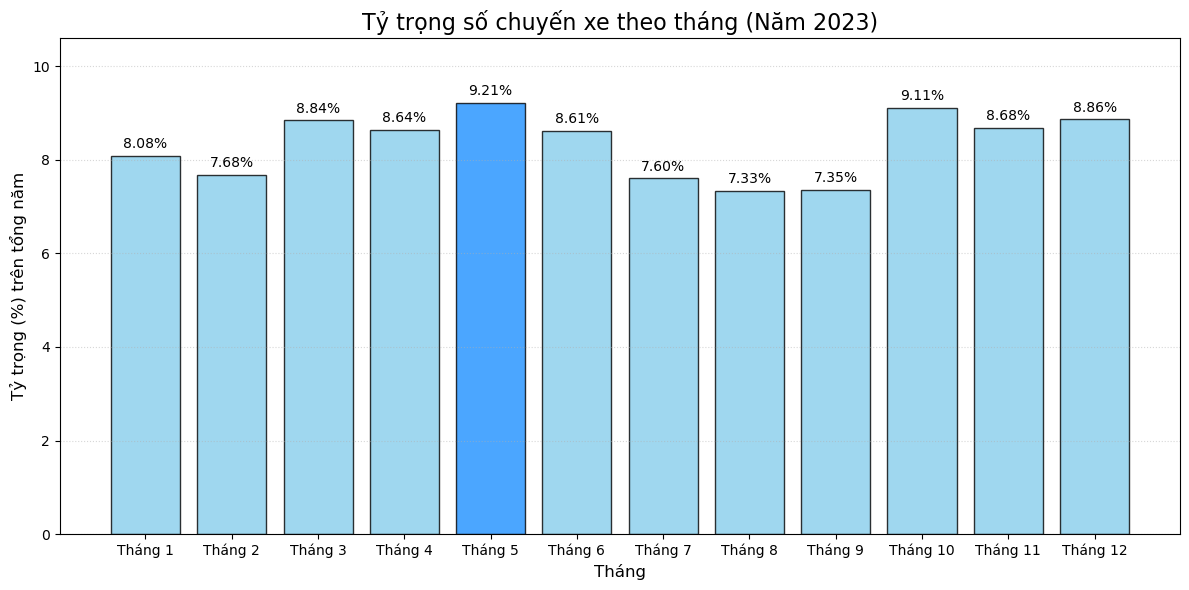

In [9]:
plt.figure(figsize=(12, 6))

# Format màu sắc cho đẹp
month_labels = [f"Tháng {idx}" for idx in kpi_monthly['pickup_month']]
colors = ['dodgerblue' if _ == kpi_monthly['percent_of_annual_trips'].max() else 'skyblue' for _ in kpi_monthly['percent_of_annual_trips']]
bars = plt.bar(month_labels, kpi_monthly['percent_of_annual_trips'], 
               color=colors, edgecolor='black', alpha=0.8)

# Thêm nhãn % trên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0,
            yval + 0.1, 
            f'{yval:.2f}%', 
            ha='center', 
            va='bottom')

plt.title(f'Tỷ trọng số chuyến xe theo tháng (Năm 2023)', fontsize=16)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tỷ trọng (%) trên tổng năm', fontsize=12)
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.ylim(0, kpi_monthly['percent_of_annual_trips'].max() * 1.15) # Đảm bảo các nhãn văn bản không bị out ra khỏi khung hình
plt.tight_layout()

# Lưu 
# plt.savefig(f'figures/Tỉ trọng chuyến xe theo tháng', dpi=150)
plt.show()
plt.close()

<h3 style="text-align:center;">Trực quan hóa doanh thu theo tháng</h3>

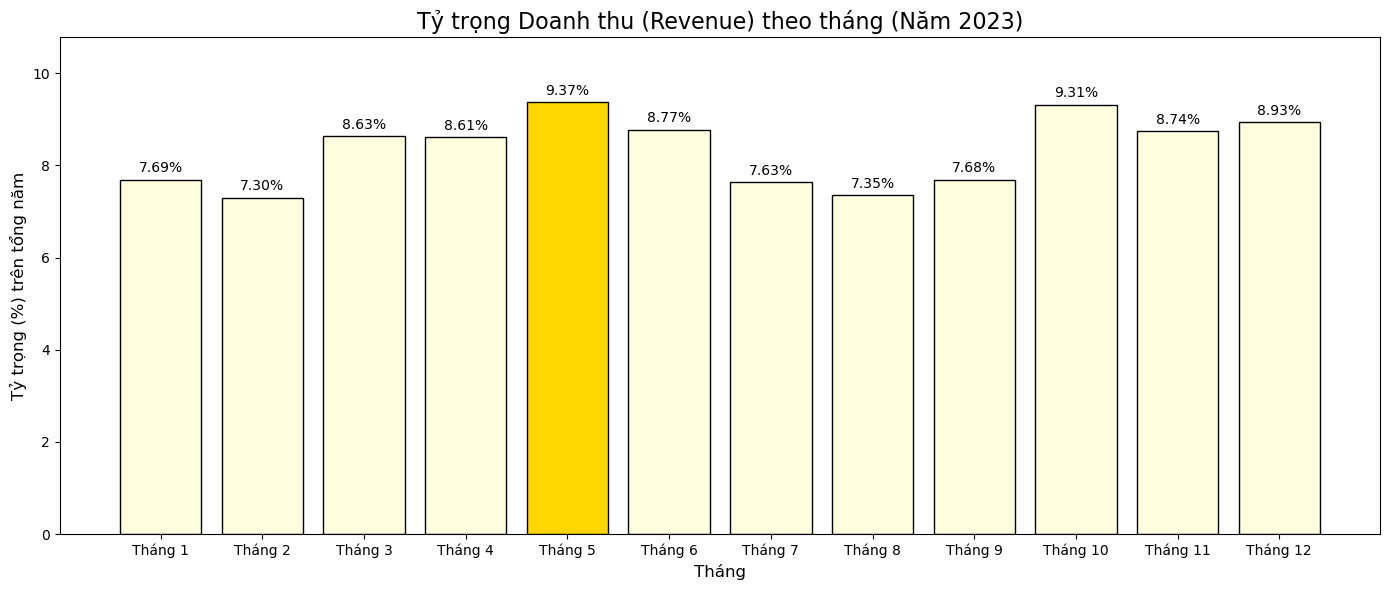

In [10]:
plt.figure(figsize=(14, 6))

month_revenue_labels = [f"Tháng {idx}" for idx in kpi_monthly['pickup_month']]
colors = ['gold' if _ == kpi_monthly['percent_of_annual_revenue'].max() else 'lightyellow' for _ in kpi_monthly['percent_of_annual_revenue']]
bars = plt.bar(month_revenue_labels, kpi_monthly['percent_of_annual_revenue'], 
               color=colors, edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.1,
        f'{yval:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title(f'Tỷ trọng Doanh thu (Revenue) theo tháng (Năm 2023)', fontsize=16)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tỷ trọng (%) trên tổng năm', fontsize=12)
plt.ylim(0, kpi_monthly['percent_of_annual_revenue'].max() * 1.15) 
plt.tight_layout()

# Lưu 
# plt.savefig(f'figures/Tỉ trọng revenue theo tháng', dpi=150)
plt.show()
plt.close()

<h3 style="text-align:center;">Minh họa theo tuần</h3>

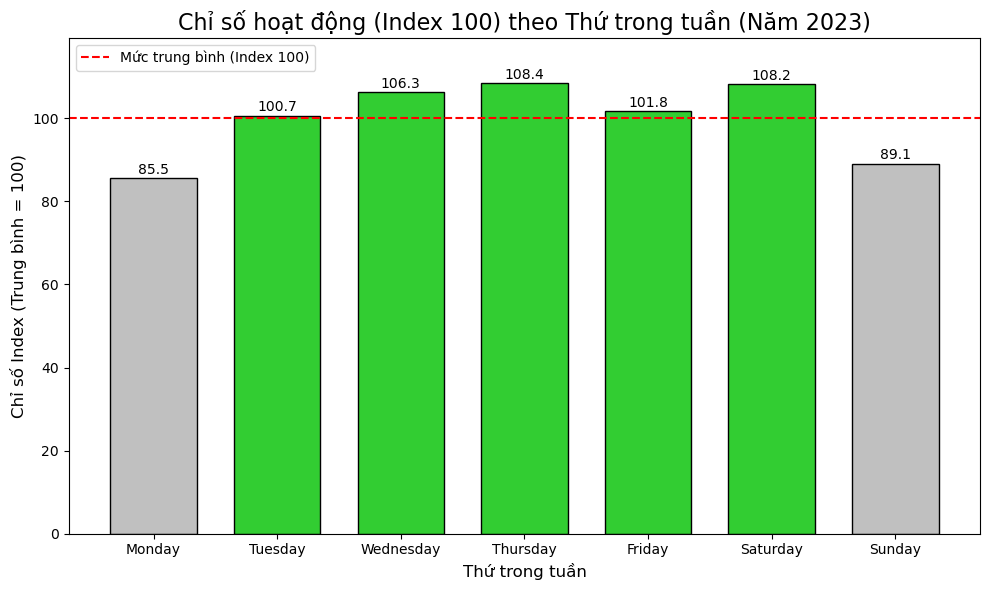

In [11]:
plt.figure(figsize=(10, 6))
# Tô màu khác nhau cho các giá trị trên/dưới 100
colors = ['silver' if _ < 100 else 'limegreen' for _ in kpi_dow['index_dow_trips']]
bars = plt.bar(kpi_dow['pickup_dow'], kpi_dow['index_dow_trips'], 
               color=colors, 
               edgecolor='black',
               width=0.7
               )

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,  # Vị trí X (ở giữa cột)
        yval + 0.3,                          # Vị trí Y (cao hơn đỉnh cột 1 chút)
        f'{yval:.1f}',                       # Văn bản (làm tròn 1 số lẻ, ví dụ: 110.5)
        ha='center',                        # Căn lề ngang (horizontal alignment)
        va='bottom'                          # Căn lề dọc (vertical alignment)
    )

# Thêm ngưỡng
plt.axhline(y=100, color='red', linestyle='--', label='Mức trung bình (Index 100)')

plt.title(f'Chỉ số hoạt động (Index 100) theo Thứ trong tuần (Năm 2023)', fontsize=16)
plt.xlabel('Thứ trong tuần', fontsize=12)
plt.ylabel('Chỉ số Index (Trung bình = 100)', fontsize=12)
plt.ylim(0, kpi_dow['index_dow_trips'].max() * 1.1) # Đảm bảo các nhãn văn bản không bị cắt khỏi khung hình
plt.legend()
plt.tight_layout()

# Save fig
# plt.savefig(f'figures/Chỉ số hoạt động theo thứ trong tuần', dpi=150)
plt.show()
plt.close()

<h3 style="text-align:center;">Lấy ra top 20 điểm đón nhiều nhất</h3>

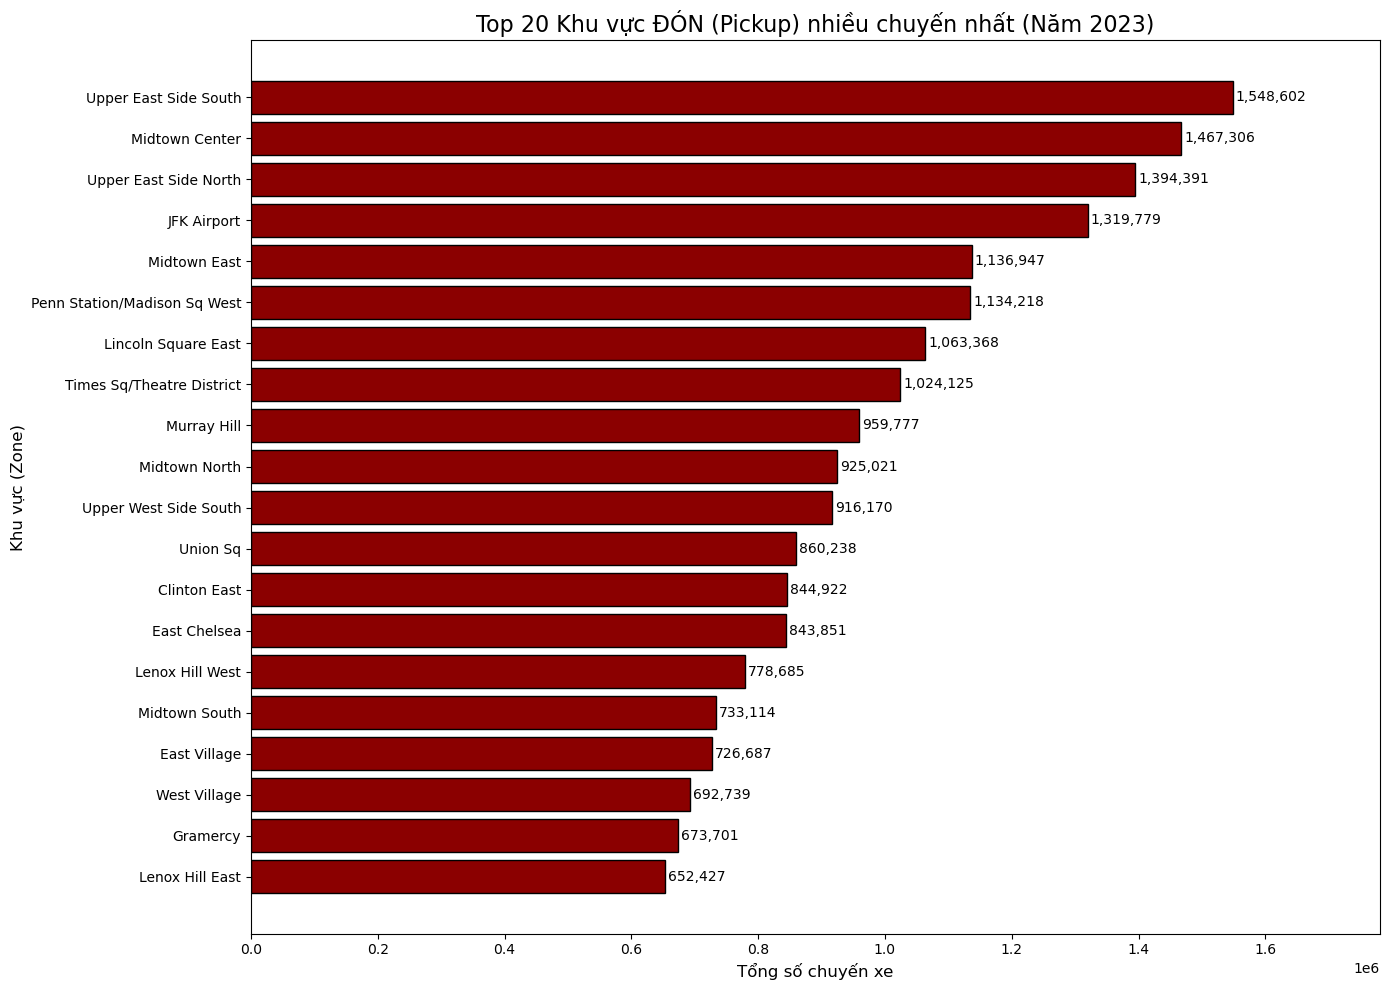

In [12]:
# Lấy Top 20
top_20_pu = PU_kpi.nlargest(n=20, columns='total_trips').sort_values(by='total_trips', ascending=True)

plt.figure(figsize=(14, 10))
bars = plt.barh(top_20_pu['PU_Zone'], top_20_pu['total_trips'], 
                color='darkred', edgecolor='black')

plt.title(f'Top 20 Khu vực ĐÓN (Pickup) nhiều chuyến nhất (Năm 2023)', fontsize=16)
plt.xlabel('Tổng số chuyến xe', fontsize=12)
plt.ylabel('Khu vực (Zone)', fontsize=12)

for bar in bars:
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, 
             f'{int(bar.get_width()):,}', 
             va='center', ha='left')
    

plt.xlim(0, PU_kpi['total_trips'].max() * 1.15)
plt.tight_layout()
# plt.savefig( f'figures/top_20_pickup_zones', dpi=150)
plt.show()
plt.close()

<h3 style="text-align:center;">Lấy top 20 điểm đến nhiều nhất</h3>

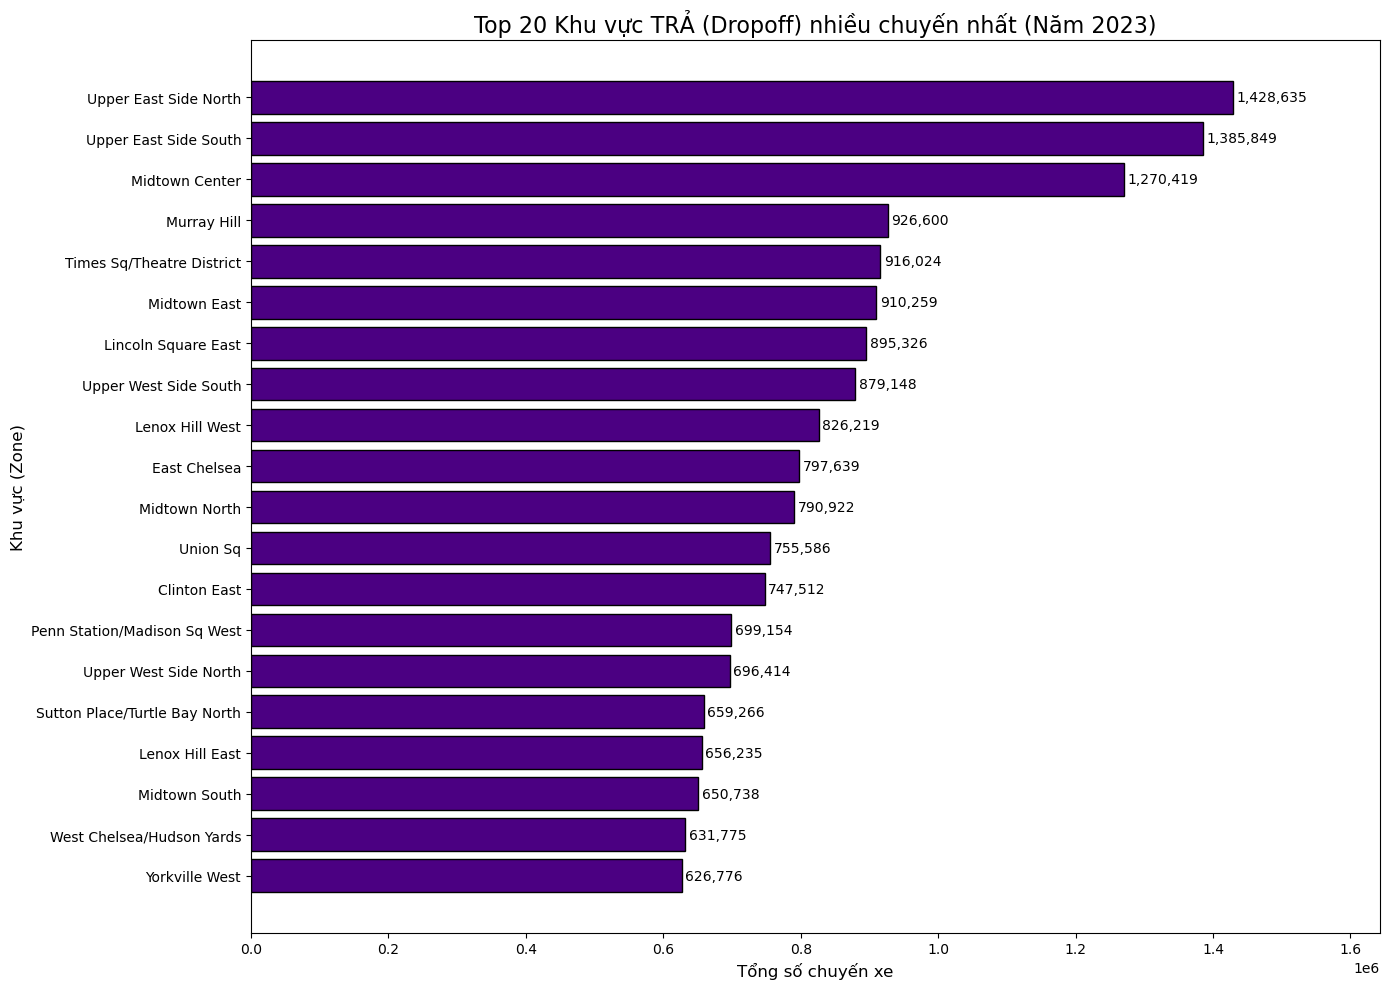

In [13]:
# lấy Top 20
top_20_do = DO_kpi.nlargest(20, 'total_trips').sort_values('total_trips', ascending=True)

plt.figure(figsize=(14, 10))
bars = plt.barh(top_20_do['DO_Zone'], top_20_do['total_trips'], 
                color='indigo', edgecolor='black')

plt.title(f'Top 20 Khu vực TRẢ (Dropoff) nhiều chuyến nhất (Năm 2023)', fontsize=16)
plt.xlabel('Tổng số chuyến xe', fontsize=12)
plt.ylabel('Khu vực (Zone)', fontsize=12)

# Format
for bar in bars:
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, 
             f'{int(bar.get_width()):,}', 
             va='center', 
             ha='left')

plt.xlim(0, DO_kpi['total_trips'].max() * 1.15)
plt.tight_layout()

# plt.savefig(f'figures/top_20_dropoff_zone', dpi=150)
plt.show()
plt.close()

In [14]:
kpi_hourly

,pickup_hour,total_trips,median_speed_mph,median_duration_min,p95_distance_miles
0,0,777767,12.379047,11.733333,15.91
1,1,532914,12.949840,10.983333,11.37
2,2,351584,13.471622,10.466667,9.32
3,3,228909,14.305103,10.400000,11.16
4,4,146806,16.050817,11.766667,17.99
5,5,150570,17.090200,11.250000,19.39
6,6,456912,14.062394,9.466667,18.33
7,7,933999,11.229284,10.283333,16.69
8,8,1307416,9.322676,11.550000,10.60
9,9,1465532,8.884138,11.916667,9.07


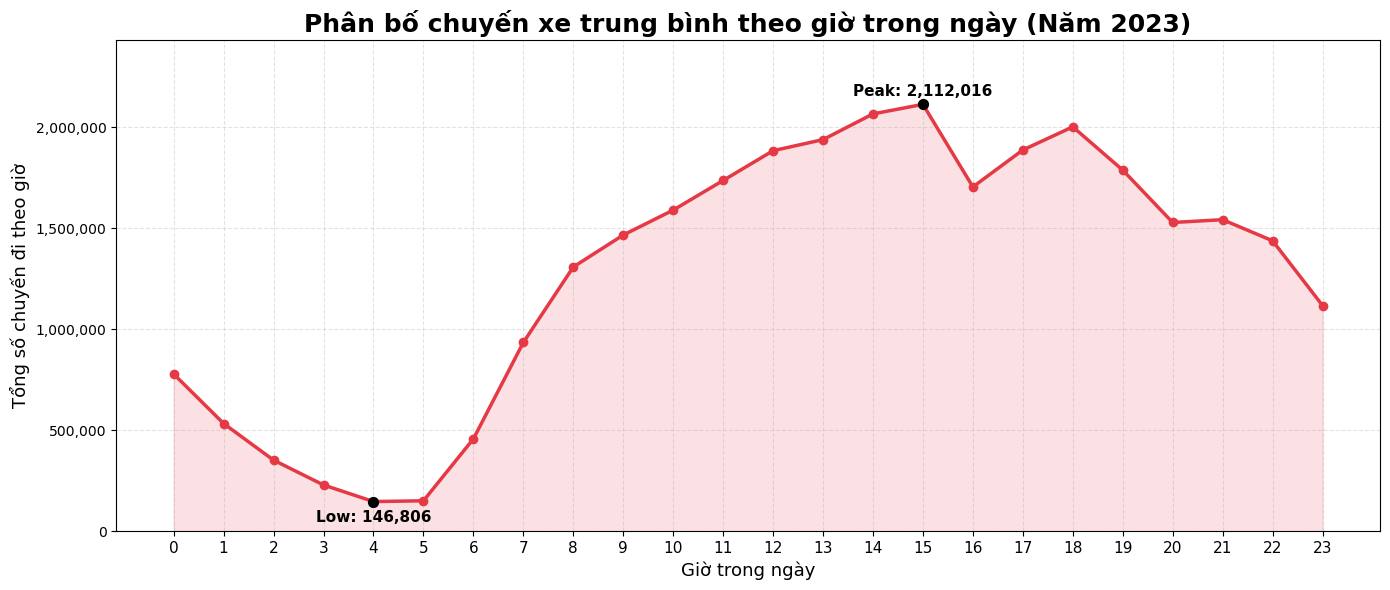

In [15]:
import matplotlib.ticker as mticker

plt.figure(figsize=(14, 6))

# Vẽ đường
plt.plot(
    kpi_hourly['pickup_hour'],
    kpi_hourly['total_trips'],
    color='#e63946',         
    linewidth=2.5,
    marker='o',
    markersize=6
)

# Tô nền phía dưới
plt.fill_between(
    kpi_hourly['pickup_hour'],
    kpi_hourly['total_trips'],
    color='#e63946',
    alpha=0.15
)

plt.title(
    'Phân bố chuyến xe trung bình theo giờ trong ngày (Năm 2023)',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Giờ trong ngày', fontsize=13)
plt.ylabel('Tổng số chuyến đi theo giờ', fontsize=13)

plt.xticks(range(0, 24), fontsize=11)

# Format
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.grid(True, linestyle='--', alpha=0.35)

# Find peak
max_idx = kpi_hourly['total_trips'].idxmax()
max_hour = int(kpi_hourly.loc[max_idx, 'pickup_hour'])
max_value = int(kpi_hourly.loc[max_idx, 'total_trips'])

plt.scatter(max_hour, max_value, color='black', s=50, zorder=5)
plt.text(
    max_hour,
    max_value + max_value * 0.02,
    f"Peak: {max_value:,}",
    ha='center',
    fontsize=11,
    fontweight='bold'
)

# Find lowest
min_idx = kpi_hourly['total_trips'].idxmin()
min_value = int(kpi_hourly['total_trips'].min())

plt.scatter(min_idx, min_value, s=50, color='black', zorder=5)
plt.text(
    min_idx, min_value - min_value*0.3,
    f"Low: {min_value:,}",
    ha='center',
    fontsize=11,
    va='top',
    fontweight='bold'
)
plt.ylim(0, kpi_hourly['total_trips'].max() * 1.15)
plt.tight_layout()

# plt.savefig(f'figures/Phân bố chuyến xe trung bình theo giờ trong ngày', dpi=150)
plt.show()
plt.close()


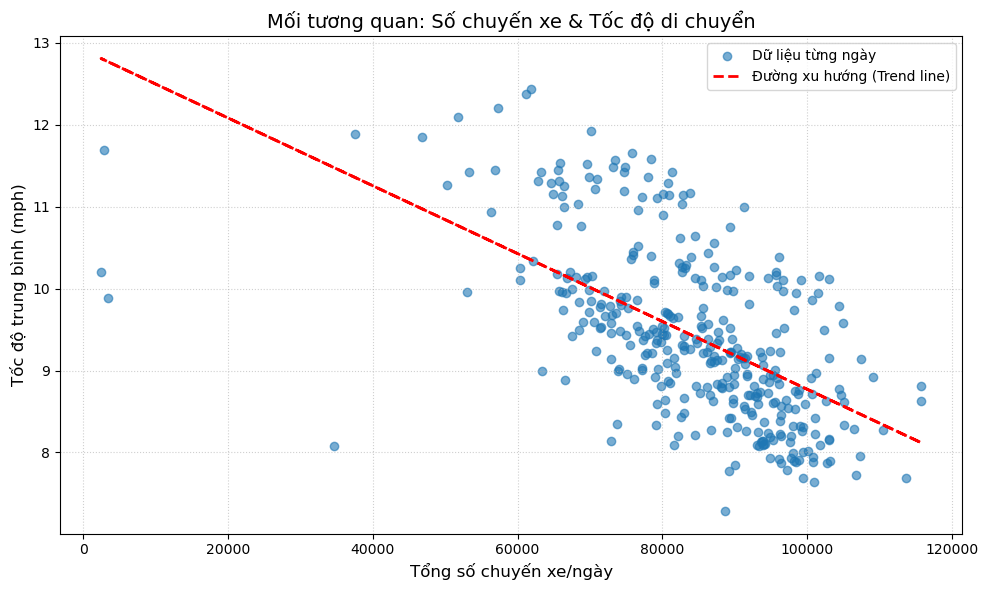

In [16]:
df = kpi_daily.dropna(subset=['total_trips', 'median_speed_mph'])
df['pickup_date'] = pd.to_datetime(df['pickup_date'])

# Vẽ biểu đồ
x = df["total_trips"]
y = df["median_speed_mph"]

plt.figure(figsize=(10,6))

# Vẽ các điểm 
plt.scatter(x, y, color='#1f77b4', alpha=0.6, label="Dữ liệu từng ngày")

# Vẽ đường xu hướng (Trend line)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, linestyle='--', label="Đường xu hướng (Trend line)")

plt.title("Mối tương quan: Số chuyến xe & Tốc độ di chuyển", fontsize=14)
plt.xlabel("Tổng số chuyến xe/ngày", fontsize=12)
plt.ylabel("Tốc độ trung bình (mph)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

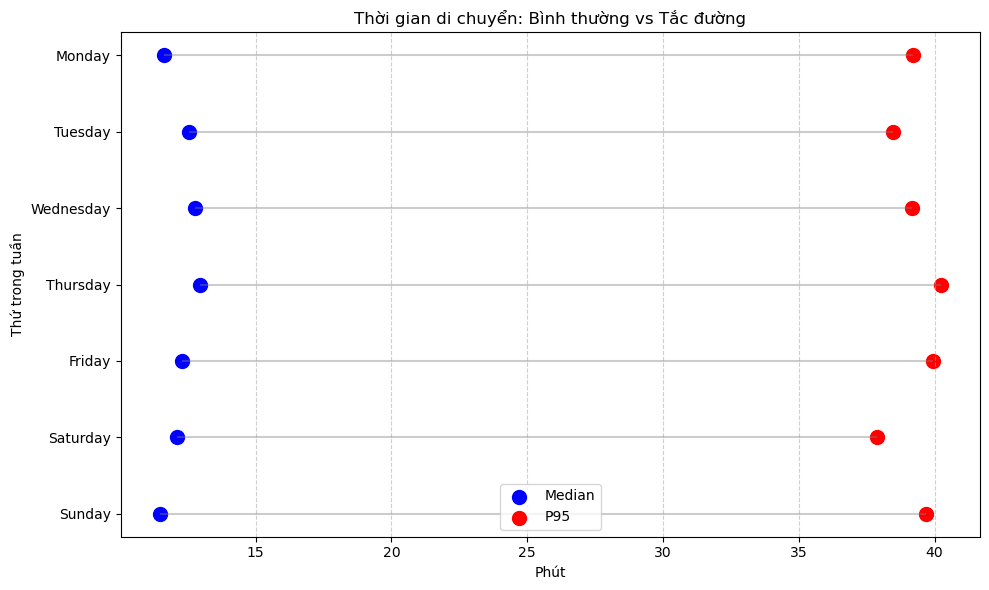

In [17]:
plt.figure(figsize=(10,6))
plt.hlines(kpi_dow['pickup_dow'], kpi_dow['median_duration_minutes'], kpi_dow['p95_duration_minutes'], color='grey', alpha=0.4)
plt.scatter(kpi_dow['median_duration_minutes'], kpi_dow['pickup_dow'], color='blue', s=100, label='Median')
plt.scatter(kpi_dow['p95_duration_minutes'], kpi_dow['pickup_dow'], color='red', s=100, label='P95')

plt.title('Thời gian di chuyển: Bình thường vs Tắc đường')
plt.xlabel('Phút')
plt.ylabel('Thứ trong tuần')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()